In [1]:
import glob
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from time_resolved_storage_helpers import sort_func, shrink_array_roll

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

## Parameter Definitions

First, define the data storage and plotting parameters

In [2]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_04_07/afc_longterm/2D')
files_to_include = 16

# plotting params
mpl.rcParams.update({'font.sans-serif': 'Helvetica',
                     'font.size': 12})
cmap_name = 'magma'
cmap = plt.get_cmap(cmap_name)
new_cmap = truncate_colormap(cmap, minval=0.1, maxval=1.0)

Here, define some values for plotting and data processing

In [29]:
# data processing params
signal_idler_offset_guess = 453  # verified based on bidirectional histogram maximum
idler_lim_input = (300, 1300)

Finally, experimental parameters go here.
This includes the histogram parameters, experimental rates, and setup efficiencies.

In [30]:
bin_size = 0.5  # unit: ns
storage_time = 1000  # unit: ns
repetition_time = 2000 # unit: ns

integration_time = files_to_include * 3600  # unit: s
num_pulses = integration_time * 500e3  # 500 kHz rep rate

idler_waveguide_efficiency = 0.049
signal_waveguide_efficiency = 0.07
signal_feedthrough_efficiency = 0.85
snspd_52_efficiency = 0.4532 * 0.7274   # includes filter loss and detector inefficiency
snspd_48_efficiency = 0.4790 * 0.9260

## Load Data

In [31]:
all_files = glob.glob(os.path.join(DATA_DIR, '*.npz'))
all_files.sort(key=sort_func)

# load data
all_counts = []
all_bins = []
all_freqs = []
file_numbers = []
for file in all_files:
    try:
        file_number = int(file.split('/')[-1].split('.')[0].split('_')[-1])
    except ValueError:
        file_number = 0
    file_numbers.append(file_number)

    data = np.load(file)
    counts = data['counts']
    bins = data['bins']
    freqs_start = data['freq_start']
    freqs_end = data['freq_end']
    all_counts.append(counts)
    all_bins.append(bins)
    all_freqs.append((freqs_start, freqs_end))

## Experiment Performance Checks

This cell confirms that:
1. The laser maintained a stable frequency through the experiment and did not unlock
2. The pair source cavity did not drift unreasonably far from the pump laser

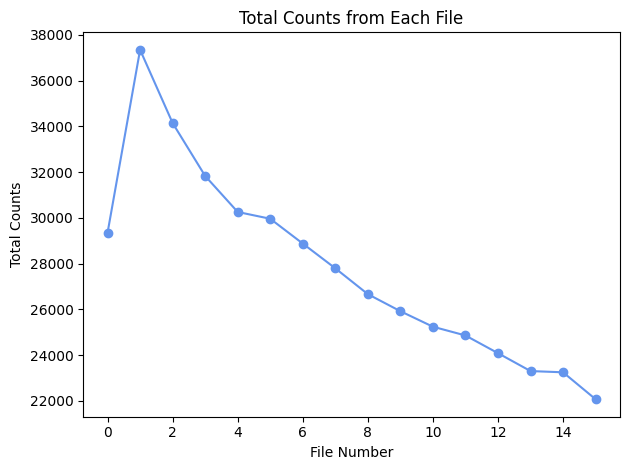

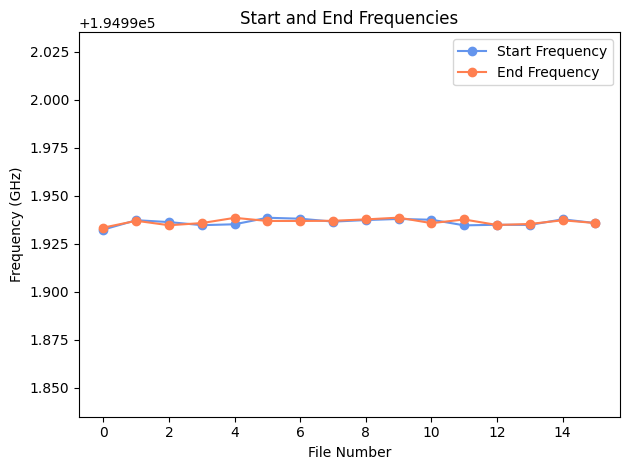

In [32]:
# plot total number of counts from each file
all_sum = np.sum(all_counts, axis=(1,2))
plt.plot(file_numbers, all_sum,
         marker='o', color='cornflowerblue')
plt.xlabel('File Number')
plt.ylabel('Total Counts')
plt.title('Total Counts from Each File')
plt.tight_layout()
plt.show()

# plot frequencies
start_freqs = [freq[0] for freq in all_freqs]
end_freqs = [freq[1] for freq in all_freqs]
plt.plot(file_numbers, start_freqs,
         color='cornflowerblue', marker='o', label='Start Frequency')
plt.plot(file_numbers, end_freqs,
         color='coral', marker='o', label='End Frequency')
plt.xlabel('File Number')
plt.ylabel('Frequency (GHz)')
plt.title('Start and End Frequencies')
plt.ylim(194991.935 - 0.1, 194991.935 + 0.1)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
all_hist = np.sum(all_counts[:files_to_include], axis=0)

# input zoom
signal_start = (idler_lim_input[0] + signal_idler_offset_guess)
signal_end = (idler_lim_input[1] + signal_idler_offset_guess)
idler_start = idler_lim_input[0]
idler_end = idler_lim_input[1]
input_zoom = all_hist[signal_start:signal_end,
                      idler_start:idler_end]

# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess) + 2000
signal_end = (idler_lim_input[1] + signal_idler_offset_guess) + 2000
idler_start = idler_lim_input[0]
idler_end = idler_lim_input[1]
echo_zoom = all_hist[signal_start:signal_end,
                     idler_start:idler_end]

## Recovery of Bidirectional Histograms using Diagonal Sums

These cells also identify the primary candidate diagonal for echo analysis

In [34]:
# compute diagonals
start_diag = 0
end_diag = all_hist.shape[0] - idler_lim_input[1]
offsets = np.arange(start_diag, end_diag, 1)
offsets = offsets * -1
diags = [np.diagonal(all_hist, offset=offset)[idler_lim_input[0]:idler_lim_input[1]]
         for offset in offsets]
diag_sum = np.sum(diags, axis=1)

# convert from offset to signal-idler arrival time in ns
# bin size for experiment is 500 ps
time_arr = offsets * -bin_size

# get input and echo counts coincidence histogram
# echo is shifted by 1 us to coincide temporally with input
input_idx = np.where(np.logical_and(time_arr > (signal_idler_offset_guess*0.5)-25,
                                    time_arr < (signal_idler_offset_guess*0.5)+25))[0]
echo_idx = input_idx + int(storage_time / bin_size)

input_center = time_arr[np.argmax(diag_sum)]

echo_center = 2456  # value based on maximum contrast in echo histogram after rebinning

## Square Rebinning

Here, we rebin the histogram with square bins, such that the center of the coincidence peak lies diagonally across one square bin.

First, do the rebinning

In [35]:
rebin_factors = np.arange(4, 41, 1)  # unit: no. of bins
rebinned_hists = []

for factor in rebin_factors:
    offset_0 = -echo_center
    rebinned_array = shrink_array_roll(all_hist, factor=factor, offset_0=offset_0)
    rebinned_hists.append(rebinned_array)

Next, we plot the diagonal for each to extract $g^{(2)}$ and error rate

In [36]:
all_diagonal_sums = []
for factor, hist in zip(rebin_factors, rebinned_hists):
    end_diag = hist.shape[0] - (idler_lim_input[1] // factor)
    offsets = np.arange(0, end_diag, 1)
    offsets = offsets * -1
    diags = [np.diagonal(hist, offset=offset)[idler_lim_input[0]//factor:idler_lim_input[1]//factor]
             for offset in offsets]
    diag_sum = np.sum(diags, axis=1)
    all_diagonal_sums.append(diag_sum)

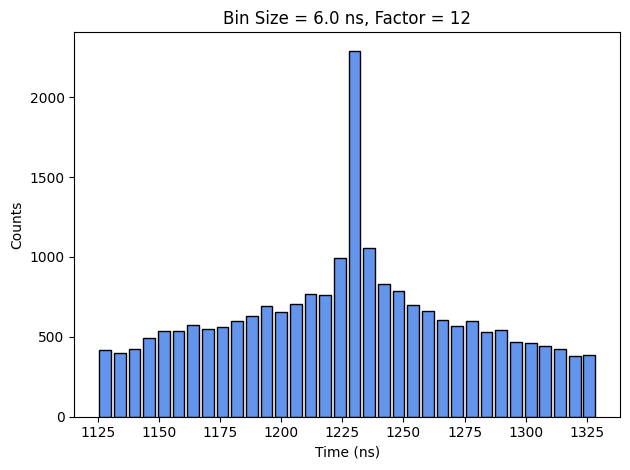

In [37]:
factor_idx_to_plot = 8
width = 200  # unit: ns

# timing calculations
diagonal_to_plot = all_diagonal_sums[factor_idx_to_plot]
factor_to_plot = rebin_factors[factor_idx_to_plot]
bin_size_time = factor_to_plot * bin_size
time_center = echo_center * bin_size
time_bins = np.arange(len(diagonal_to_plot)) * bin_size_time

# plotting calculations
idx_to_plot = np.where(np.logical_and(time_bins >= time_center - width/2, time_bins <= time_center + width/2))[0]

plt.bar(time_bins[idx_to_plot], all_diagonal_sums[factor_idx_to_plot][idx_to_plot],
        width=0.8*bin_size_time, color='cornflowerblue', edgecolor='k')
plt.title(f'Bin Size = {rebin_factors[factor_idx_to_plot] * bin_size} ns, Factor = {rebin_factors[factor_idx_to_plot]}')
plt.xlabel('Time (ns)')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

In [38]:
contrast_vals = []
contrast_err = []
center_idxs = []
for factor, diagonal in zip(rebin_factors, all_diagonal_sums):
    bin_size_time = factor * bin_size
    time_center = echo_center * bin_size
    time_bins = np.arange(len(diagonal)) * bin_size_time
    idx_to_analyze = np.where(np.logical_and(time_bins >= time_center - width/2, time_bins <= time_center + width/2))[0]
    counts_to_analyze = diagonal[idx_to_analyze]
    center_idx = np.argmax(counts_to_analyze)
    center_idxs.append(center_idx)
    center_counts = np.max(counts_to_analyze)
    bg_left_counts = counts_to_analyze[center_idx - 1]
    bg_right_counts = counts_to_analyze[center_idx + 1]
    bg_counts = (bg_left_counts + bg_right_counts) / 2

    contrast = center_counts / bg_counts
    contrast_vals.append(contrast)

    center_err = np.sqrt(center_counts)
    bg_err = np.sqrt(bg_left_counts + bg_right_counts) / 2
    contrast_err.append(contrast * np.sqrt((center_err / center_counts) ** 2 + (bg_err / bg_counts) ** 2))

Text(0, 0.5, 'Center Bin Contrast')

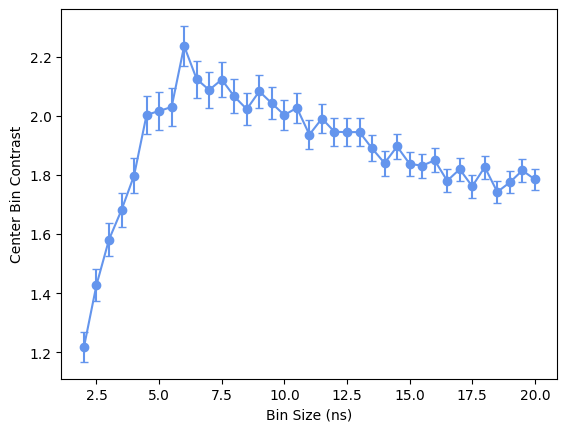

In [39]:
plt.errorbar(np.array(rebin_factors) * bin_size, contrast_vals, yerr=contrast_err,
             marker='o', capsize=3, color='cornflowerblue')
plt.xlabel('Bin Size (ns)')
plt.ylabel('Center Bin Contrast')

In [40]:
idx_to_plot = np.argmax(contrast_vals)
factor = rebin_factors[idx_to_plot]
print(idx_to_plot, factor, contrast_vals[idx_to_plot], contrast_err[idx_to_plot])

8 12 2.23609756097561 0.0679753449713698


We then plot the best bin size here

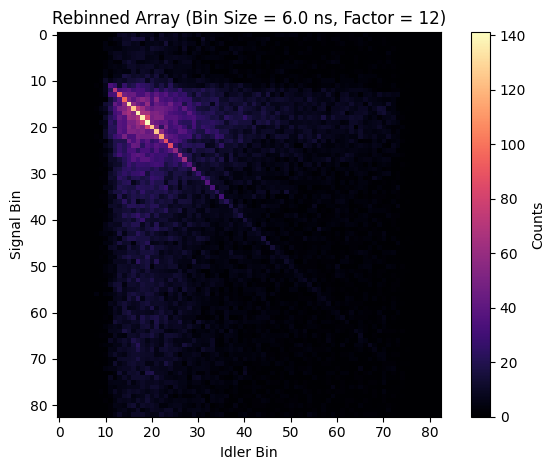

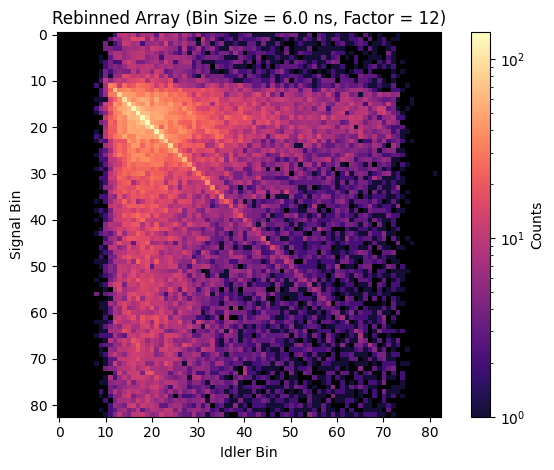

In [41]:
idx_to_plot = np.argmax(contrast_vals)
factor = rebin_factors[idx_to_plot]
rebinned_array = rebinned_hists[idx_to_plot]

# plot summed histogram (zoom on echo)
signal_start = (idler_lim_input[0] + signal_idler_offset_guess + 2000) // factor + 1
signal_end = (idler_lim_input[1] + signal_idler_offset_guess + 2000) // factor + 1
idler_start = idler_lim_input[0] // factor
idler_end = idler_lim_input[1] // factor
echo_zoom = rebinned_array[signal_start:signal_end, idler_start:idler_end]

time_bins = np.arange(len(echo_zoom)) * factor * bin_size

# plot non-log scale
plt.imshow(echo_zoom, cmap=cmap)
plt.xlabel('Idler Bin')
plt.ylabel('Signal Bin')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {factor * bin_size} ns, Factor = {factor})')
plt.tight_layout()
plt.show()

# plot log scale
plt.imshow(echo_zoom, cmap=new_cmap,
           norm=colors.LogNorm(vmin=1, vmax=echo_zoom.max()))
plt.gca().set_facecolor('black')
plt.xlabel('Idler Bin')
plt.ylabel('Signal Bin')
plt.colorbar(label='Counts')
plt.title(f'Rebinned Array (Bin Size = {factor * bin_size} ns, Factor = {factor})')
plt.tight_layout()
plt.show()

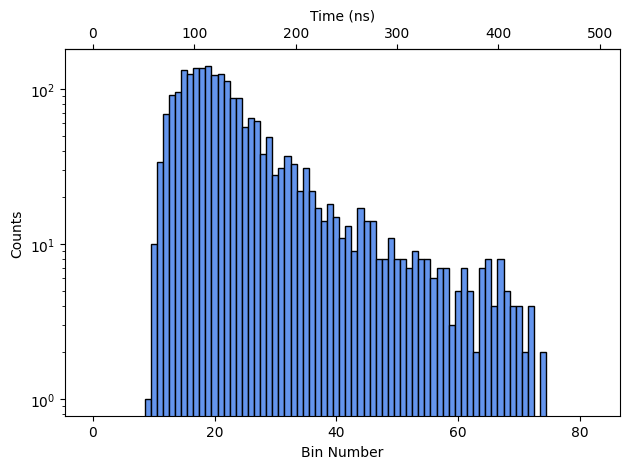

In [42]:
time_bin_diagonal = np.diagonal(echo_zoom)
time_bin_off_diagonal_right = np.diagonal(echo_zoom, offset=1)
time_bin_off_diagonal_left = np.diagonal(echo_zoom, offset=-1)
off_diagonal = (time_bin_off_diagonal_right + time_bin_off_diagonal_left) / 2
bin_numbers = np.arange(len(time_bin_diagonal))

# functions for axes
def bin_to_time(bin_number):
    return bin_number * factor * bin_size

def time_to_bin(time):
    return time / (factor * bin_size)

fig, ax = plt.subplots()
ax.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
# ax.bar(bin_numbers[1:], off_diagonal, width=1, color='coral', edgecolor='k')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Counts')
ax.set_yscale('log')
sec_ax = ax.secondary_xaxis('top', functions=(bin_to_time, time_to_bin))
sec_ax.set_xlabel('Time (ns)')

# ax.axvline(10 - 0.5, color='k', ls='--')
# ax.axvline(73 - 0.5, color='k', ls='--')

fig.tight_layout()

## Entropy and Rate Analysis

First, calculate entropy and total number of ebits for different portions of the pulse

In [43]:
# frame_sizes = np.arange(10, 70, 1, dtype=int)
frame_sizes = np.arange(2, 65, 1, dtype=int)
min_start_idx = 0
max_max_start_idx = len(time_bin_diagonal) - min(frame_sizes)
entropies = np.empty((len(frame_sizes), max_max_start_idx + 1))
entropies[:] = np.nan
total_ebits = np.empty((len(frame_sizes), max_max_start_idx + 1))
total_ebits[:] = np.nan
rate_ebits = np.empty((len(frame_sizes), max_max_start_idx + 1))
rate_ebits[:] = np.nan

for i, bin_num in enumerate(frame_sizes):
    max_start_idx = len(time_bin_diagonal) - bin_num
    pulse_time = bin_num * bin_size * factor  # unit: ns
    pulse_duty_cycle = pulse_time / repetition_time

    for j, start_idx in enumerate(range(min_start_idx, max_start_idx)):
        end_idx = start_idx + bin_num
        time_bins_to_analyze = time_bin_diagonal[start_idx:end_idx]
        counts_tot = np.sum(time_bins_to_analyze)
        amplitudes = time_bins_to_analyze / counts_tot
        entropy = 0
        for amplitude in amplitudes:
            if amplitude > 0:
                entropy -= amplitude * np.log2(amplitude)

        entropies[i, j] = entropy
        total_counts_entropy = counts_tot * entropy
        total_ebits[i, j] = total_counts_entropy

        ebit_rate = total_counts_entropy / (integration_time * pulse_duty_cycle)
        rate_ebits[i, j] = ebit_rate

all_efficiencies = idler_waveguide_efficiency * signal_waveguide_efficiency * signal_feedthrough_efficiency * snspd_52_efficiency * snspd_48_efficiency
rate_ebits_no_loss = rate_ebits / all_efficiencies

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_50825/1955801452.py:21: RuntimeWarning: invalid value encountered in divide
  amplitudes = time_bins_to_analyze / counts_tot


Plot the entropy per photon given frame size

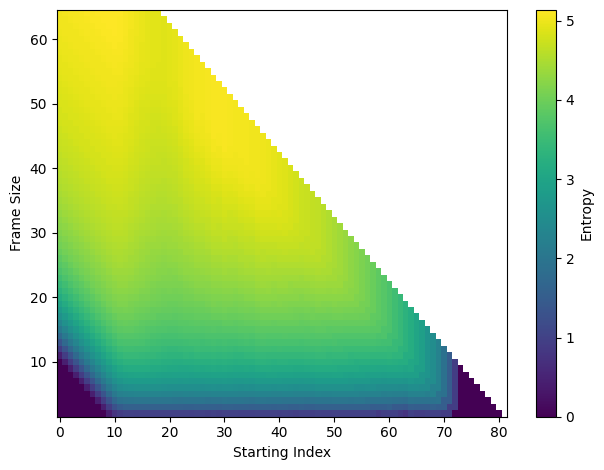

In [45]:
X, Y = np.meshgrid(np.arange(max_max_start_idx+1), frame_sizes)

plt.pcolormesh(X, Y, entropies, cmap='viridis', shading='nearest')
plt.xlabel('Starting Index')
plt.ylabel('Frame Size')
plt.colorbar(label='Entropy')

plt.tight_layout()

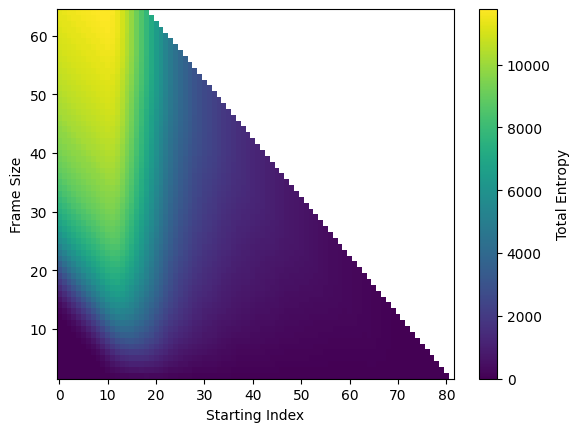

In [46]:
plt.pcolormesh(X, Y, total_ebits, cmap='viridis', shading='nearest')
plt.xlabel('Starting Index')
plt.ylabel('Frame Size')
plt.colorbar(label='Total Entropy')

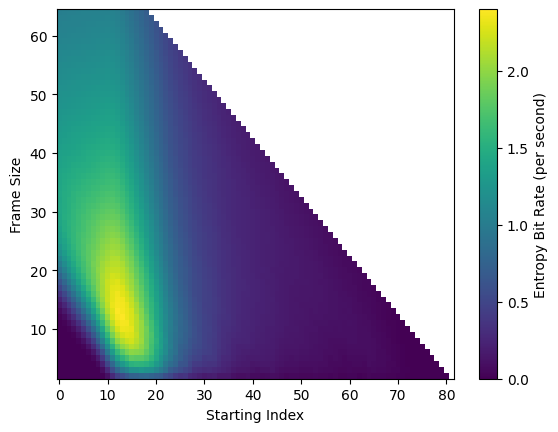

In [47]:
plt.pcolormesh(X, Y, rate_ebits, cmap='viridis', shading='nearest')
plt.xlabel('Starting Index')
plt.ylabel('Frame Size')
plt.colorbar(label='Entropy Bit Rate (per second)')

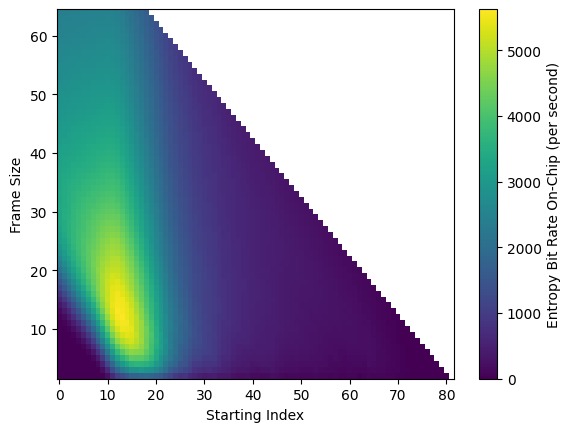

In [48]:
plt.pcolormesh(X, Y, rate_ebits_no_loss, cmap='viridis', shading='nearest')
plt.xlabel('Starting Index')
plt.ylabel('Frame Size')
plt.colorbar(label='Entropy Bit Rate On-Chip (per second)')

Text(0, 0.5, 'Entropy Per Photon')

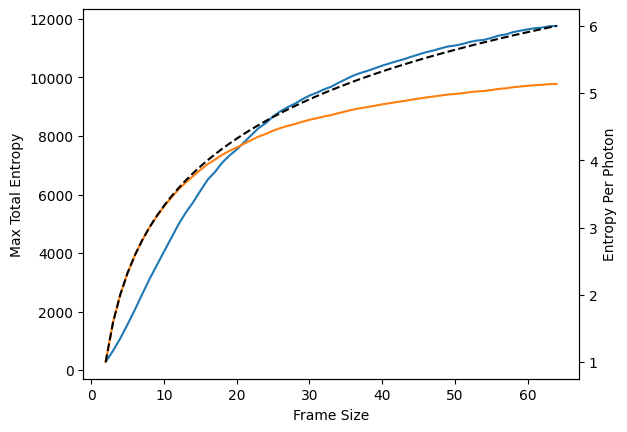

In [49]:
max_total_entropy = np.nanmax(total_ebits, axis=1)
max_entropy_idx = np.nanargmax(total_ebits, axis=1)
max_entropy = np.array([entropies[i, max_entropy_idx[i]] for i in range(len(frame_sizes))])

fig, ax = plt.subplots()
ax2 = ax.twinx()
ax.plot(frame_sizes, max_total_entropy)
ax2.plot(frame_sizes, max_entropy, color='tab:orange')
ax2.plot(frame_sizes, np.log2(frame_sizes), ls='--', color='k')
ax.set_xlabel('Frame Size')
ax.set_ylabel('Max Total Entropy')
ax2.set_ylabel('Entropy Per Photon')

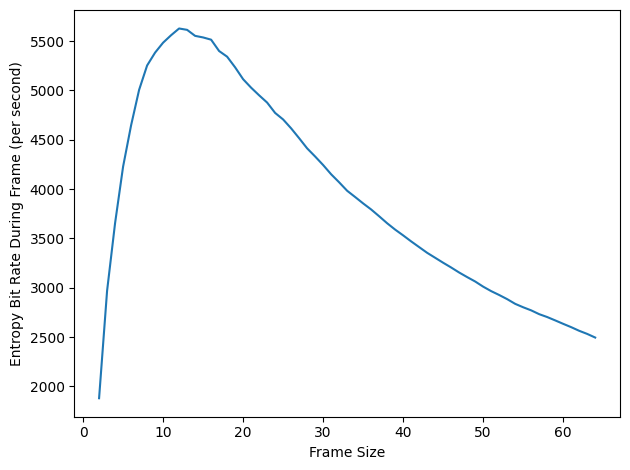

In [58]:
max_rates = np.nanmax(rate_ebits_no_loss, axis=1)

fig, ax = plt.subplots()

ax.plot(frame_sizes, max_rates)
ax.set_xlabel('Frame Size')
ax.set_ylabel('Entropy Bit Rate During Frame (per second)')

fig.tight_layout()

In [59]:
fig.savefig('rate_vs_frame_size.pdf')

In [60]:
max_rate_idx = np.argmax(max_rates)
max_rate = max_rates[max_rate_idx]
max_frame_size = frame_sizes[max_rate_idx]
max_frame_start = np.nanargmax(rate_ebits_no_loss[max_rate_idx])

print(f'Max Rate: {max_rate:.2f} Hz')
print(f'Max Frame Size: {max_frame_size} bins ({max_frame_size*factor*bin_size} ns)')
print(f'Max Frame Start: bin index {max_frame_start}')

Max Rate: 5628.49 Hz
Max Frame Size: 12 bins (72.0 ns)
Max Frame Start: bin index 13


In [61]:
for frame_size, max_idx, entropy_per, rate in zip(frame_sizes, max_entropy_idx, max_entropy, max_rates):
    # print(frame_size, max_idx, entropy_per)
    print(f'{frame_size:02} {max_idx:02} {entropy_per:0.2f} {rate:0.2f}')

02 18 1.00 1879.67
03 17 1.58 2968.82
04 16 2.00 3655.82
05 15 2.32 4227.79
06 15 2.58 4646.59
07 15 2.81 5005.65
08 15 3.00 5252.99
09 14 3.16 5383.97
10 13 3.31 5484.65
11 13 3.44 5560.30
12 13 3.56 5628.49
13 12 3.67 5614.60
14 12 3.76 5553.69
15 12 3.86 5537.71
16 12 3.94 5515.02
17 12 4.01 5399.94
18 12 4.08 5342.69
19 11 4.14 5234.72
20 11 4.19 5114.30
21 12 4.25 5028.34
22 11 4.30 4951.00
23 11 4.35 4877.46
24 11 4.39 4772.32
25 11 4.44 4706.12
26 11 4.48 4616.11
27 11 4.51 4516.16
28 11 4.54 4413.24
29 11 4.57 4330.56
30 11 4.60 4244.06
31 11 4.63 4150.41
32 11 4.65 4068.95
33 10 4.67 3983.22
34 11 4.70 3919.83
35 11 4.73 3854.90
36 11 4.75 3793.63
37 10 4.78 3724.74
38 10 4.79 3653.87
39 11 4.81 3589.32
40 10 4.83 3530.77
41 10 4.85 3469.87
42 10 4.87 3411.87
43 10 4.88 3354.01
44 10 4.90 3303.78
45 10 4.92 3253.38
46 10 4.93 3205.19
47 10 4.95 3154.26
48 10 4.96 3107.84
49 10 4.98 3063.32
50 10 4.99 3011.00
51 10 5.00 2965.59
52 10 5.01 2926.39
53 10 5.03 2884.30
54 10 5.03 2

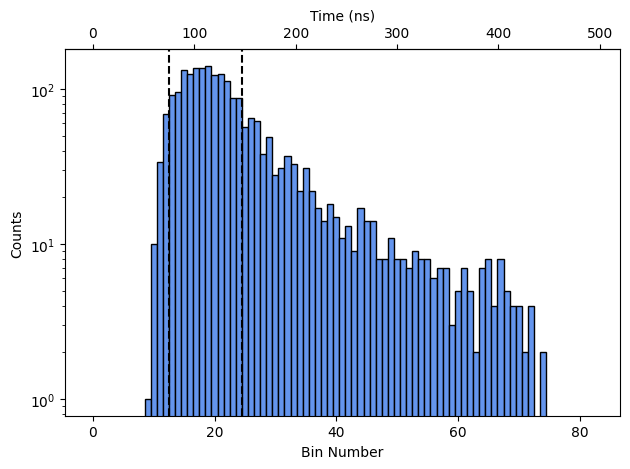

In [62]:
fig, ax = plt.subplots()
ax.bar(bin_numbers, time_bin_diagonal, width=1, color='cornflowerblue', edgecolor='k')
# ax.bar(bin_numbers[1:], off_diagonal, width=1, color='coral', edgecolor='k')
ax.set_xlabel('Bin Number')
ax.set_ylabel('Counts')
ax.set_yscale('log')
sec_ax = ax.secondary_xaxis('top', functions=(bin_to_time, time_to_bin))
sec_ax.set_xlabel('Time (ns)')

ax.axvline(max_frame_start-0.5, color='k', ls='--')
ax.axvline(max_frame_start+max_frame_size-0.5, color='k', ls='--')

fig.tight_layout()

In [63]:
fig.savefig('optimal_bin_size.pdf')